# 英语名字趋势分析

In [428]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import wordcloud

# Pylab结合了pyplot和numpy, 对交互式使用而言比较方便，既可以画图又可以进行简单的计算
# 但是建议分别导入使用
from pylab import mpl
mpl.rcParams['font.sans-serif']='SimHei' # 解决seaborn中文字体的问题
plt.rc('figure',figsize = (10,10))
%matplotlib inline 
#功能是内嵌绘图，而且可以省略plt.show()这一步
plt.rcParams['font.sans-serif']='SimHei'
# pyecharts相关设置
import pyecharts.options as opts
from pyecharts.faker import Faker
from pyecharts.charts import Line

In [2]:
data = pd.read_csv('NationalNames.csv')

In [3]:
data.head()

,Id,Name,Year,Gender,Count
0,1,Mary,1880,F,7065
1,2,Anna,1880,F,2604
2,3,Emma,1880,F,2003
3,4,Elizabeth,1880,F,1939
4,5,Minnie,1880,F,1746


In [4]:
# 查看数据的结构
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1924665 entries, 0 to 1924664
Data columns (total 5 columns):
Id        int64
Name      object
Year      int64
Gender    object
Count     int64
dtypes: int64(3), object(2)
memory usage: 73.4+ MB


## 1.查看2010-2017年，Top15的男、女英文名

In [257]:
# 以年为顺序展示数据框: data['Year']是一个Series。Series对应的数据就是同一行剩余的数据
data.loc[data['Year'],:]
# 从另一个方面而言，data.loc[data['Year'],:]实现了将Year作为索引的功能

,Id,Name,Year,Gender,Count
1880,1881,Cleo,1880,M,5
1880,1881,Cleo,1880,M,5
1880,1881,Cleo,1880,M,5
1880,1881,Cleo,1880,M,5
1880,1881,Cleo,1880,M,5
...,...,...,...,...,...
2017,2018,Cora,1881,F,969
2017,2018,Cora,1881,F,969
2017,2018,Cora,1881,F,969
2017,2018,Cora,1881,F,969


### 男♂

In [292]:
top15_boy = data.loc[(data['Year'].isin(list(range(2010,2018))))&(data['Gender']=='M'),:]
top15_boy.head()
# group by names and sum their counts
top15_boy = top15_boy.groupby('Name').Count.sum().nlargest(15)
top15_boy

Name
Noah         145195
Jacob        140091
Mason        133535
Liam         133019
William      131241
Ethan        125561
Michael      122265
Alexander    118376
James        112387
Daniel       111658
Elijah       110075
Aiden        109852
Jayden       109122
Benjamin     107648
Matthew      105429
Name: Count, dtype: int64

In [7]:
# 用top15_boy.index找出每一个名字的index
name = top15_boy.index
name = list(name)
value = list(top15_boy.values)
# 暂时没法用wordcloud，待解决

In [8]:
# 找出top15boy的数据
data_top15_boy = data.loc[(data['Year'].isin(list(range(2010,2018))))&
                         (data['Gender']=='M')&(data['Name'].isin(list(top15_boy.index))),:]
data_top15_boy

,Id,Name,Year,Gender,Count
1677731,1677732,Jacob,2010,M,22117
1677732,1677733,Ethan,2010,M,18000
1677733,1677734,Michael,2010,M,17342
1677734,1677735,Jayden,2010,M,17171
1677735,1677736,William,2010,M,17048
...,...,...,...,...,...
1910518,1910519,Ethan,2017,M,12389
1910519,1910520,Daniel,2017,M,11640
1910520,1910521,Matthew,2017,M,11611
1910521,1910522,Aiden,2017,M,11259


In [293]:
# 用sort_value函数重新排序data_top15_boy
data_top15_boy.sort_values(by = ['Year','Count'], inplace = True, ascending = False)
data_top15_boy

D:\Anaconda\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,Id,Name,Year,Gender,Count
1910505,1910506,Liam,2017,M,18728
1910506,1910507,Noah,2017,M,18326
1910507,1910508,William,2017,M,14904
1910508,1910509,James,2017,M,14232
1910510,1910511,Benjamin,2017,M,13733
...,...,...,...,...,...
1677746,1677747,Matthew,2010,M,14126
1677748,1677749,Elijah,2010,M,13891
1677749,1677750,James,2010,M,13877
1677752,1677753,Benjamin,2010,M,12428


用seaborn把data_top15_boy的增长趋势画出来

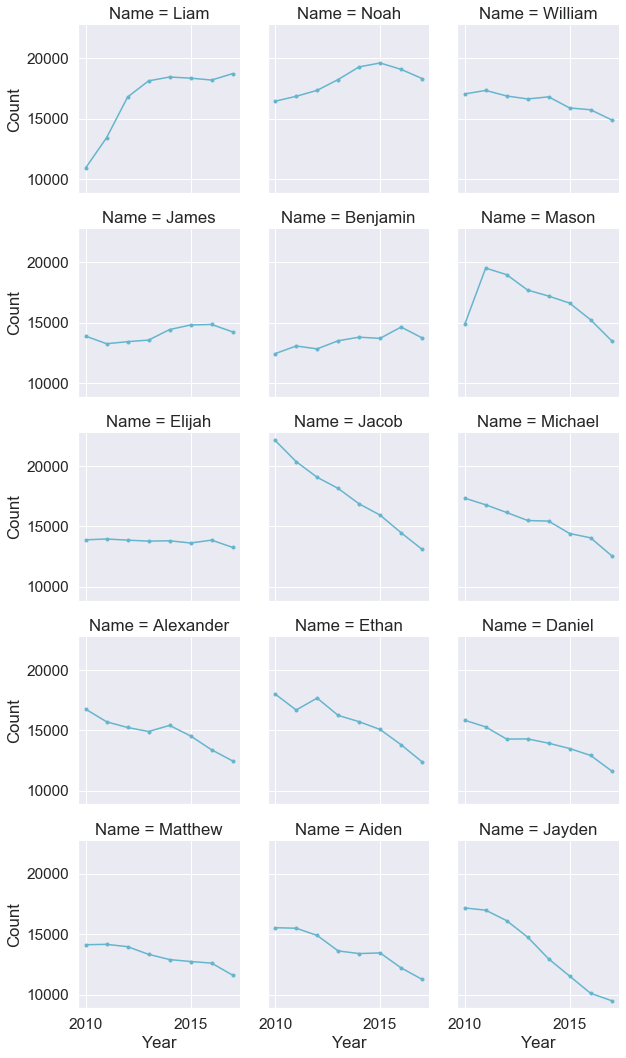

In [10]:
# 设定sns参数
sns.set(font_scale = 1.4)
# 用sns.FacetGrid设定Grid
g = sns.FacetGrid(data_top15_boy, col='Name', col_wrap = 3)
# 正式把趋势图画出来
g = g.map(plt.plot,'Year','Count',color = 'c', marker = '.')


## 女♀

In [11]:
top15_girl = data.loc[(data['Year'].isin(list(range(2010,2018)))&(data['Gender']=='F')),:]
# 同样地，用groupby函数和Count.Sum()把名字统计出来
top15_girl = top15_girl.groupby('Name').Count.sum().nlargest(15)

把前30位女的的名字显示出来

In [12]:
list(data.loc[(data['Year'].isin(list(range(2010,2018)))&(data['Gender']=='F')),:].groupby('Name').Count.sum().nlargest(30).index)

['Emma',
 'Sophia',
 'Olivia',
 'Isabella',
 'Ava',
 'Mia',
 'Emily',
 'Abigail',
 'Madison',
 'Elizabeth',
 'Charlotte',
 'Chloe',
 'Ella',
 'Amelia',
 'Avery',
 'Sofia',
 'Evelyn',
 'Harper',
 'Addison',
 'Grace',
 'Natalie',
 'Victoria',
 'Lily',
 'Aubrey',
 'Lillian',
 'Zoey',
 'Hannah',
 'Brooklyn',
 'Layla',
 'Samantha']

In [289]:
name = list(top15_girl.index)
value = list(top15_girl.values)

把女的名字变化趋势用sns展示出来

D:\Anaconda\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


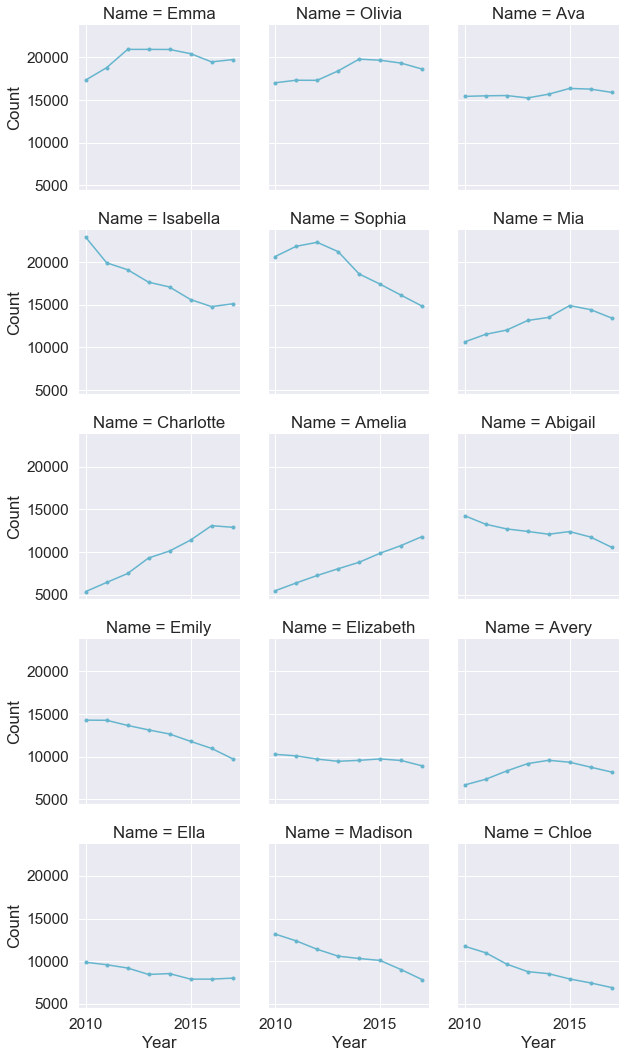

In [296]:
# 首先找到数据
data_top15_girl = data.loc[(data['Year'].isin(list(range(2010,2018))))&
                          (data['Gender']=='F')&(data['Name'].isin(top15_girl.index)),:]
# 然后根据它们的年份和数量进行排序
data_top15_girl.sort_values(by = ['Year','Count'], ascending = False,
                           inplace = True)

# 正式用sns.FacetGrid和map画图
# 1.预设值字体大小
sns.set(font_scale=1.4)
# 2.创建sns.FacetGrid实例
g = sns.FacetGrid(data_top15_girl, col='Name', col_wrap=3)
# 3.进行映射：选择映射函数plt.plot和探索的变量Year和Count
g.map(plt.plot, 'Year', 'Count', color = 'c', marker = '.')

## 2. 查看每个时代最潮的名字

* 1920-2017

首先筛选出数据，并且用pd.cut()函数将对应年份的数据进行标记，格式是pd.cut(DataFrame['colname'], bins = [part1, part2, part3,...], label = ['label1','label2','label3',...])

In [297]:
data_decades = data[data['Year']>=1920] # 如果用loc慢的令人发指
data_decades['decade'] = pd.cut(data_decades['Year'],[1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2018],
                               labels = ['20后','30后','40后', '50后','60后','70后','80后','90后','00后','10后'],right=False)
data_decades

D:\Anaconda\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [415]:
decade = data_decades.groupby(['decade','Gender','Name']).Count.sum()

In [414]:
print(decade.index.levels[:])

[['20后', '30后', '40后', '50后', '60后', '70后', '80后', '90后', '00后', '10后'], ['F', 'M'], ['Aaban', 'Aabha', 'Aabid', 'Aabir', 'Aabriella', 'Aada', 'Aadam', 'Aadan', 'Aadarsh', 'Aaden', 'Aadesh', 'Aadhav', 'Aadhavan', 'Aadhi', 'Aadhira', 'Aadhvik', 'Aadhvika', 'Aadhya', 'Aadhyan', 'Aadi', 'Aadian', 'Aadil', 'Aadilynn', 'Aadin', 'Aadish', 'Aadison', 'Aadit', 'Aadith', 'Aadithya', 'Aaditri', 'Aaditya', 'Aadiv', 'Aadon', 'Aadrian', 'Aadrika', 'Aadrit', 'Aadriti', 'Aadvi', 'Aadvik', 'Aadvika', 'Aadya', 'Aadyn', 'Aafia', 'Aafiya', 'Aafiyah', 'Aafreen', 'Aagam', 'Aagna', 'Aahaan', 'Aahan', 'Aahana', 'Aaheli', 'Aahil', 'Aahir', 'Aahliyah', 'Aahna', 'Aahron', 'Aaidan', 'Aaiden', 'Aaidyn', 'Aaila', 'Aailiyah', 'Aailyah', 'Aaima', 'Aaira', 'Aairah', 'Aaisha', 'Aaishah', 'Aaiyana', 'Aaiza', 'Aaja', 'Aajah', 'Aajaylah', 'Aajon', 'Aakanksha', 'Aakarsh', 'Aakash', 'Aakeem', 'Aakil', 'Aakilah', 'Aakira', 'Aakiyah', 'Aakriti', 'Aala', 'Aalaiya', 'Aalaiyah', 'Aalana', 'Aalanah', 'Aalani', 'Aalap', 'Aalaya',

In [417]:
# 找出每个年代最潮的名字

# 1. 首先，根据年代和性别进行聚类。由上可知level1为年代，level2为性别
decade = decade.groupby(level = [0,1])
# 2. 接着，取【不同年代不同性别】的【取的最多】的名字：用nlargest(1)
decade = decade.nlargest(1)

decade

decade  Gender  decade  Gender  Name    
20后     F       20后     F       Mary        701746.0
        M       20后     M       Robert      576362.0
30后     F       30后     F       Mary        572942.0
        M       30后     M       Robert      590716.0
40后     F       40后     F       Mary        640023.0
        M       40后     M       James       795660.0
50后     F       50后     F       Mary        625558.0
        M       50后     M       James       843489.0
60后     F       60后     F       Lisa        496972.0
        M       60后     M       Michael     833254.0
70后     F       70后     F       Jennifer    581772.0
        M       70后     M       Michael     707647.0
80后     F       80后     F       Jessica     469472.0
        M       80后     M       Michael     663690.0
90后     F       90后     F       Jessica     303086.0
        M       90后     M       Michael     462314.0
00后     F       00后     F       Emily       223658.0
        M       00后     M       Jacob       273793.0
10后  

将时代最潮的名字用柱状图统计出来

[None]

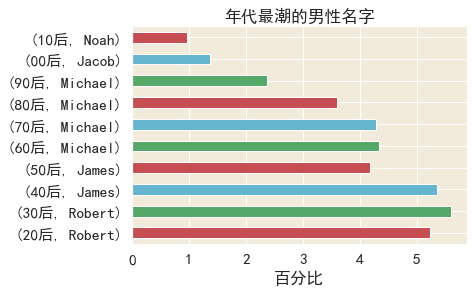

In [440]:
# 判断每个观测的属性3的值是否等于'M'
decade_boy_count = decade.iloc[decade.index.get_level_values(3)=='M']

# 用reset_index(index=[levels],drop=True)去掉重复的columns
decade_boy_count = decade_boy_count.reset_index(level = [0,1,3],drop = True)

# 用groupby函数对data_decades聚类后统计频数 
decade_boy_total = data_decades[data_decades['Gender']=='M'].groupby('decade').Count.sum()

# 统计出每个年代最潮的男♂名
decade_boy_pct = (decade_boy_count/decade_boy_total*100).round(2)
ax = decade_boy_pct.plot.barh(title='年代最潮的男性名字',color=['r','g','c'])
ax.set_xlabel('百分比')
ax.set_ylabel('')
ax.set(facecolor='#f2eada')


[None]

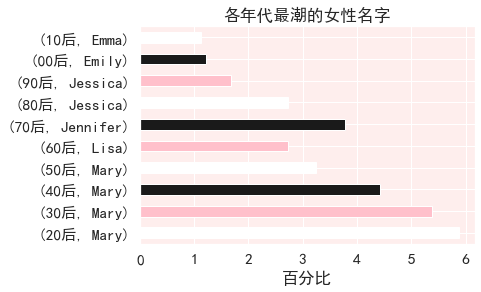

In [442]:
decade_girl_count = decade.iloc[decade.index.get_level_values(3)=='F'].reset_index(level = [0,1,3], drop=True)
decade_girl_total = data_decades[data_decades['Gender']=='F'].groupby('decade').Count.sum()
decade_girl_pct = (decade_girl_count/decade_girl_total*100).round(2)
ax = decade_girl_pct.plot.barh(title='各年代最潮的女性名字', color = ['w', 'pink', 'k'])
ax.set_ylabel('')
ax.set_xlabel('百分比')
ax.set(facecolor='#feeeed')


## 3. 以前很潮，现在不潮的名字

### 男

In [443]:
# 以前很潮的名字
data_popular_former = data[(data['Year'] < 1950) & (data['Count'] > 10500) &
                           (data['Gender'] == 'M')]
# 现在不潮的名字
data_not_popular_now = data[(data['Year'] > 2000) & (data['Count'] < 1000) &
                           (data['Gender'] == 'M')]

In [445]:
# set(a)&set(b)可以返回a和b的∩
boys_names_popular_former = list(set(list(data_popular_former.Name.unique())) & set
                                (list(data_not_popular_now.Name.unique())))
boys_names_popular_former

['Harold',
 'Ronald',
 'Frank',
 'Gary',
 'Donald',
 'Larry',
 'Dennis',
 'Walter',
 'Jerry',
 'Bruce',
 'Terry',
 'Douglas',
 'Gregory',
 'Arthur',
 'Roger',
 'Gerald']

已经知道了名字，现在只需要按图索骥，从data中找出这些名字的data即可

In [24]:
boys_names_popular_former_data = data[(data['Name'].isin(boys_names_popular_former)) &
                                     (data['Year']>=1920)&(data['Gender']=='M')]
boys_names_popular_former_data

,Id,Name,Year,Gender,Count
175228,175229,Frank,1920,M,16432
175231,175232,Harold,1920,M,13679
175232,175233,Walter,1920,M,13294
175235,175236,Donald,1920,M,11941
175237,175238,Arthur,1920,M,10236
...,...,...,...,...,...
1911133,1911134,Larry,2017,M,411
1911141,1911142,Gary,2017,M,403
1911196,1911197,Terry,2017,M,354
1911303,1911304,Harold,2017,M,285


[13679 13810 13594 13873 14153 13596 13309 13231 12679 11671 11659 10693
 10425  9544  9925  9165  8629  8549  8556  8302  8076  8102  8582  8663
  7979  7524  8369  8902  8142  7813  7220  7174  6963  6582  6341  6088
  5950  5749  5144  4940  4677  4439  4230  4098  3877  3541  3321  2958
  2836  2767  2727  2388  2036  1812  1680  1589  1440  1437  1242  1248
  1191  1099  1044   939   862   857   803   801   801   783   771   683
   664   602   518   519   507   433   407   413   406   377   363   343
   350   349   356   350   310   265   304   256   260   234   272   283
   287   285]
[  832   993  1042  1148  1360  1676  2287  3111  3976  4477  5634  6726
 11139 12061 14084 15483 16920 18136 20294 19835 20729 24397 27134 29235
 25509 23665 31853 34884 33516 31495 29916 29044 27809 27704 27596 26163
 27725 27181 24807 23108 21700 20816 19975 19781 18840 17620 16957 16439
 15423 14623 13616 11634  9511  8327  7667  7066  6461  6030  5757  5702
  5760  5533  5207  4708  4507  4299 

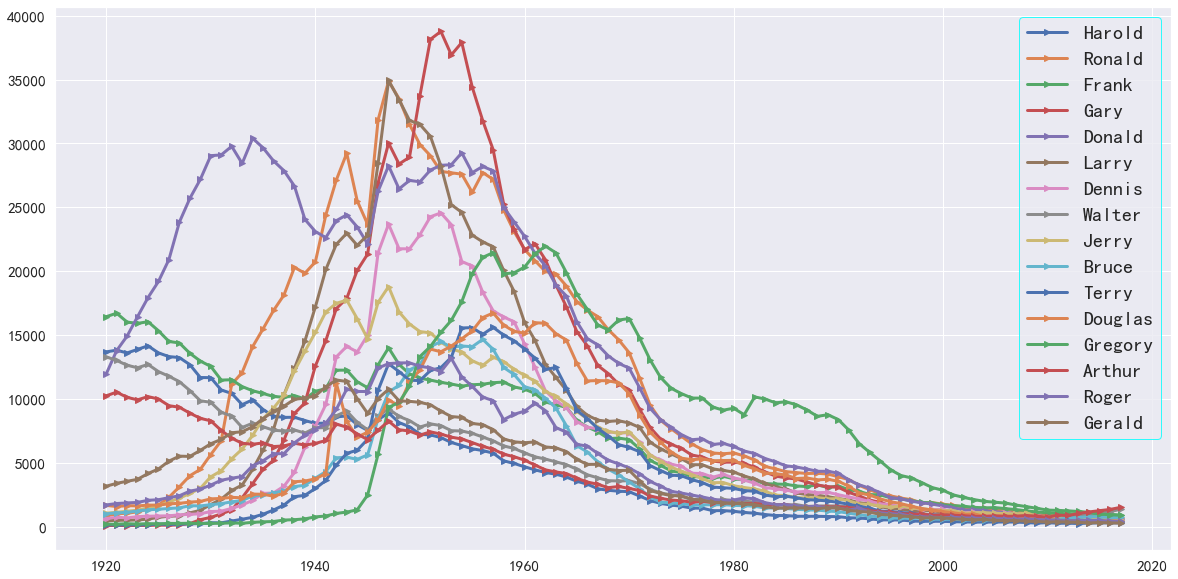

In [454]:
# 画出男名字流行趋势图

# 1.首先定义x轴
attr = list(range(1920,2018))

# 2.创建Line()实例
line = Line()

# 3.对于boys_names_popular_former中的每一个名字用for循环添加到图标上
for name in boys_names_popular_former:
    # 用Count.values来统计每种以前流行的名字的个数
    v = list(boys_names_popular_former_data[boys_names_popular_former_data['Name']==name].Count.values)
    line.add_xaxis(attr)
    line.add_yaxis(name, v)
    
# 4.用render_notebook()进行渲染
line.render_notebook()
# 但不知为何花不了，待解决

# 或者用matpltlib画出趋势图

# 1.首先定义figure的大小
plt.figure(figsize = (20,10))

# 2.其次，对于每个名字，画出来，注意label要进行设置，为legend做准备
for name in boys_names_popular_former:
    v = list(boys_names_popular_former_data[boys_names_popular_former_data['Name']==name].Count.values)
    plt.plot(attr, v, label = name, linewidth = 3, marker = '>')
    # 注意是Count.values而非Count.sum().前者是统计每个名字每个时间点上的数量，后者是统计每个名字再所有时间点上的数量总和
    print(boys_names_popular_former_data[boys_names_popular_former_data['Name']==name].Count.values)

    # 3. 最后，把legends标出来，legend的依据是labels
plt.legend(labels = boys_names_popular_former, fontsize = 20, loc = 'upper right', frameon = True, edgecolor = 'aqua')

### 女

In [26]:
data_popular_former = data[(data['Year']<1950)&(data['Gender']=='F')&
                          (data['Count']>22500)]
data_not_popular_now = data[(data['Year']>2000) & (data['Gender']=='F')&
                           (data['Count']<1000)]
girl_names_popular_former = list(set(list(data_popular_former.Name.unique()))&
                                  set(list(data_not_popular_now.Name.unique())))
girl_names_popular_former_data = data[(data['Name'].isin(girl_names_popular_former))&
                                     (data['Year'] >= 1920)&(data['Gender']=='F')]
girl_names_popular_former_data

,Id,Name,Year,Gender,Count
169456,169457,Dorothy,1920,F,36643
169457,169458,Helen,1920,F,35097
169459,169460,Ruth,1920,F,26101
169465,169466,Betty,1920,F,14017
169501,169502,Barbara,1920,F,5106
...,...,...,...,...,...
1893244,1893245,Sharon,2017,F,243
1893466,1893467,Shirley,2017,F,184
1893515,1893516,Betty,2017,F,175
1893911,1893912,Donna,2017,F,123


画出女名字流行趋势图

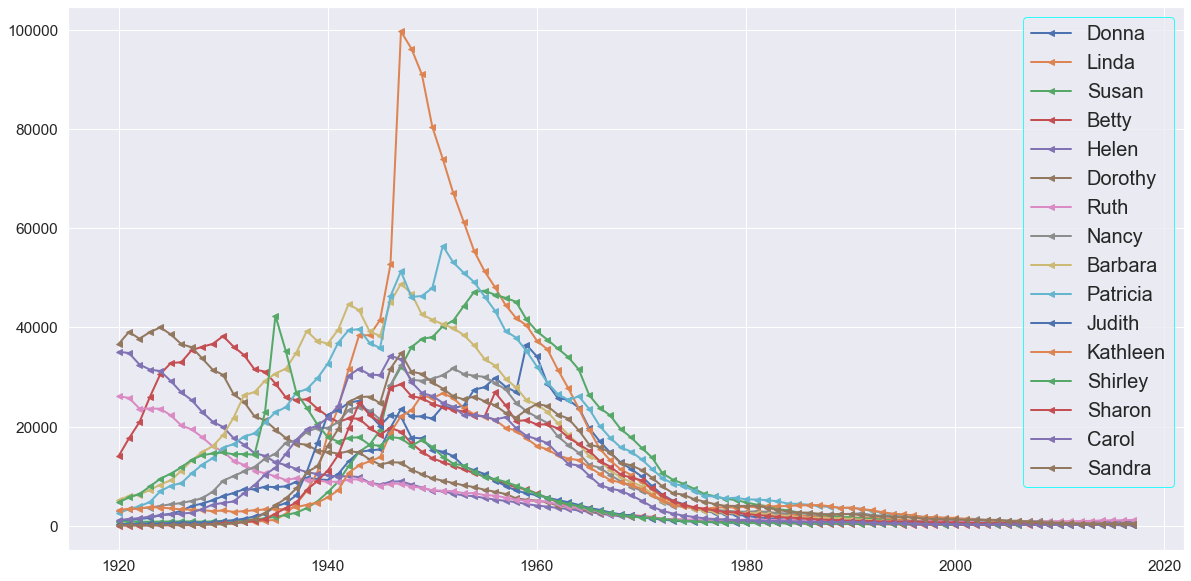

In [27]:
attr = range(1920,2018)

plt.figure(figsize=(20,10))
for name in girl_names_popular_former:
    v = girl_names_popular_former_data[girl_names_popular_former_data['Name']==name].Count.values
    plt.plot(attr, v, label = name, linewidth = 2, marker = '<')

plt.legend(loc = 'upper right', fontsize = 20, frameon = True, edgecolor = 'cyan', labels = girl_names_popular_former)


## 4. 2000年后越来越流行的名字

### 男

In [471]:
# 注意，data.loc(条件,:)和 data(条件)的效果是一样的
data_popular_now = data.loc[(data['Year'] >= 2000) & (data['Gender'] == 'M') & 
                       (data['Count']>7000),:]

# 把数据改造成数据透视表，为下一步使用corrwith()做准备
data_popular_now = data_popular_now.pivot(index = 'Name', columns = 'Year', values = 'Count')
data_popular_now

Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
Name,,,,,,,,,,,,,,,,,,
Aaron,9553.0,9535.0,9001.0,8865.0,8389.0,7802.0,8296.0,8935.0,8537.0,7969.0,7461.0,7613.0,7530.0,7301.0,7391.0,7152.0,7150.0,7165.0
Adam,8133.0,7752.0,7749.0,7683.0,7471.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adrian,NaN,NaN,NaN,NaN,NaN,NaN,7381.0,7733.0,7927.0,7631.0,7405.0,7333.0,NaN,NaN,NaN,NaN,NaN,NaN
Aidan,NaN,NaN,NaN,10062.0,9821.0,9758.0,10034.0,8420.0,7698.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aiden,NaN,NaN,NaN,NaN,7159.0,9081.0,11583.0,13101.0,15578.0,16017.0,15535.0,15492.0,14896.0,13615.0,13394.0,13449.0,12212.0,11259.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Timothy,7260.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tyler,21503.0,19271.0,18264.0,18179.0,17442.0,16985.0,15535.0,14086.0,12697.0,11540.0,10444.0,8834.0,7696.0,NaN,NaN,NaN,NaN,NaN
William,20659.0,20099.0,20122.0,19989.0,20223.0,19050.0,18955.0,18881.0,18388.0,17914.0,17048.0,17339.0,16880.0,16633.0,16809.0,15889.0,15739.0,14904.0


In [470]:
# 找出和时间关联性为正数且数值较大(大于.8)的名字的数据


# 1. 分析各个名字和时间的关联性

# 1.1 首先构造一个字典并转化成数据框
year = {'Year':list(range(2000,2018))}
year = pd.DataFrame(year, index = range(2000,2018))

# 1.2 接着使用pd.corrwith(比较的主体,axis,method)计算出每个名字和时间的相关性
data_popular_now_corr = data_popular_now.corrwith(year['Year'], axis=1)


# 2. 根据相关性找出名字和对应数据

# 2.1 找出相关性大于.8的数据的名字的index，即对应的名字
boys_names_popular_now = list(data_popular_now_corr[data_popular_now_corr > 0.8].index)

# 2.2 根据名字找出对应的数据
boys_names_popular_now_data = data[(data['Name'].isin(boys_names_popular_now))&(data['Year']>=1920)&(data['Gender'] == 'M')]


# 3. 其他处理：对数据进行瘦身，索引重置，以及melt

# 3.1 用pivot函数把数据框变为透视表形式 (目的似乎是去除多余信息并为reset_index()做准备)
boys_names_popular_now_data = boys_names_popular_now_data.pivot(index='Name', columns='Year',values='Count')

# 3.2 用reset_index()对索引进行重编排
boys_names_popular_now_data = boys_names_popular_now_data.reset_index()

# 3.3 用melt函数把数据框由透视表形式恢复到普通的DataFrame (pivot的逆操作)
boys_names_popular_now_data = boys_names_popular_now_data.melt('Name', value_name = 'Count')
boys_names_popular_now_data


,Name,Year,Count
0,Amelia,1920,NaN
1,Aria,1920,NaN
2,Camila,1920,NaN
3,Charlotte,1920,5.0
4,Evelyn,1920,24.0
...,...,...,...
975,Harper,2017,284.0
976,Mia,2017,16.0
977,Olivia,2017,10.0
978,Penelope,2017,6.0


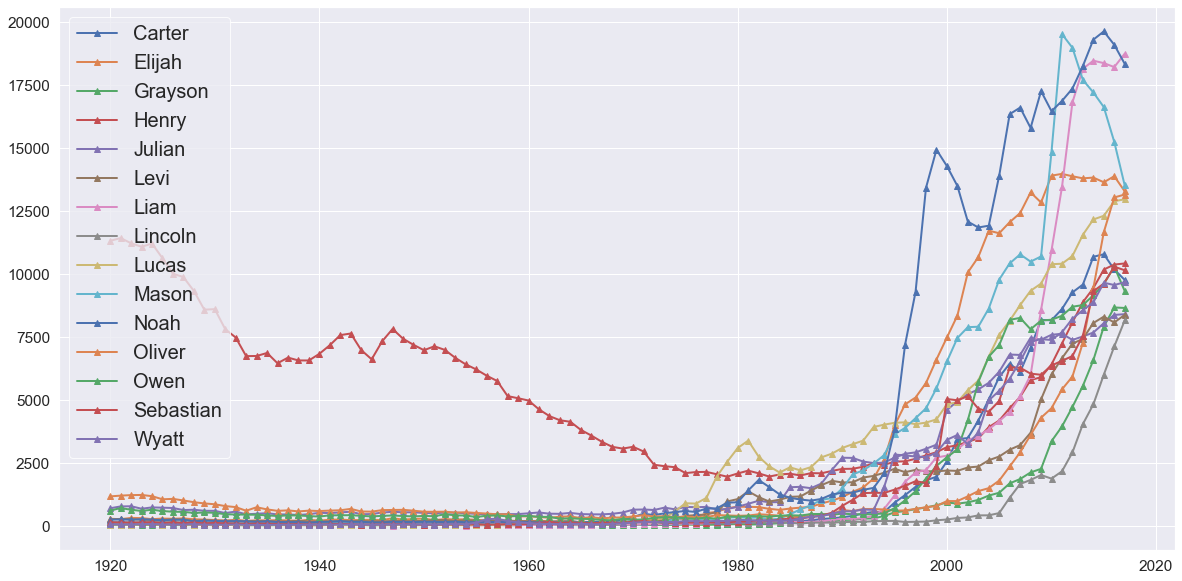

In [118]:
# 最后，利用matplotlib画出变化趋势图

plt.figure(figsize = (20,10))
attr = range(1920, 2018)
for name in boys_names_popular_now:
    v = boys_names_popular_now_data[boys_names_popular_now_data['Name']==name].Count.values
    plt.plot(attr, v, marker = '^', linewidth = 2, label = name)
plt.legend(labels=boys_names_popular_now, frameon = True, edgecolor = 'white', fontsize = 20, loc = 'upper left')


### 女

In [81]:
# 把数据挑出来 
data_popular_now = data[(data['Year']>=2000) & (data['Gender'] == 'F') &
                       (data['Count']>6000)]

# 用pivot函数做一下数据透视表
data_popular_now = data_popular_now.pivot(index = 'Name', columns = 'Year', values = 'Count')
data_popular_now


Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
Name,,,,,,,,,,,,,,,,,,
Abigail,13088.0,14807.0,15297.0,15925.0,15424.0,15749.0,15627.0,15468.0,15081.0,14387.0,14243.0,13247.0,12697.0,12405.0,12076.0,12390.0,11747.0,10551.0
Addison,NaN,NaN,NaN,NaN,NaN,NaN,7620.0,11946.0,10759.0,10659.0,10324.0,9297.0,8175.0,7727.0,6983.0,6713.0,6316.0,NaN
Alexa,NaN,NaN,NaN,NaN,NaN,NaN,6110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6050.0,NaN,NaN
Alexandra,7546.0,7041.0,6936.0,6544.0,6622.0,6317.0,6098.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alexis,17629.0,16401.0,15636.0,14866.0,13470.0,11971.0,11228.0,9909.0,9721.0,9928.0,8263.0,6521.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sydney,10242.0,9637.0,9034.0,8910.0,8364.0,7376.0,6514.0,6029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Taylor,15078.0,13690.0,11467.0,10308.0,9303.0,8671.0,8557.0,7960.0,8335.0,7582.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Victoria,10923.0,10179.0,9782.0,9243.0,8274.0,7955.0,7647.0,7431.0,7118.0,6359.0,6226.0,6888.0,6861.0,7202.0,7991.0,7606.0,7300.0,7267.0


In [120]:
# 计算名字与时间之间的相关性

data_popular_now_corr = data_popular_now.corrwith(year['Year'],axis=1)

# 将【年份和频数相关性较强的样本】的名字赋值给girls_popular_now_corr

girls_names_popular_now = data_popular_now_corr[data_popular_now_corr > .7].index
girls_names_popular_now

# 根据girls_names_popular_now找出girls_names_popular_now_data
girls_names_popular_now_data = data[
    (data['Name'].isin(girls_names_popular_now)) &
    (data['Year'] >= 1920) &
    (data['Gender'] == 'F')
]

# 还需要对girls_names_popular_now_data进行index重置和melt操作

# 1.把数据框改造成透视图格式
girls_names_popular_now_data = girls_names_popular_now_data.pivot(index = 'Name', columns = 'Year', values = 'Count')

# 2.接着进行index的重置(原来没index，现在在最左边加index)
girls_names_popular_now_data = girls_names_popular_now_data.reset_index()

# 3.最后进行melt操作，只保留Name和它对应的year的count
girls_names_popular_now_data = girls_names_popular_now_data.melt('Name', value_name = 'Count')
girls_names_popular_now_data

,Name,Year,Count
0,Amelia,1920,1054.0
1,Aria,1920,NaN
2,Avery,1920,16.0
3,Camila,1920,7.0
4,Charlotte,1920,3623.0
...,...,...,...
1269,Olivia,2017,18632.0
1270,Penelope,2017,6639.0
1271,Scarlett,2017,7679.0
1272,Sofia,2017,8134.0


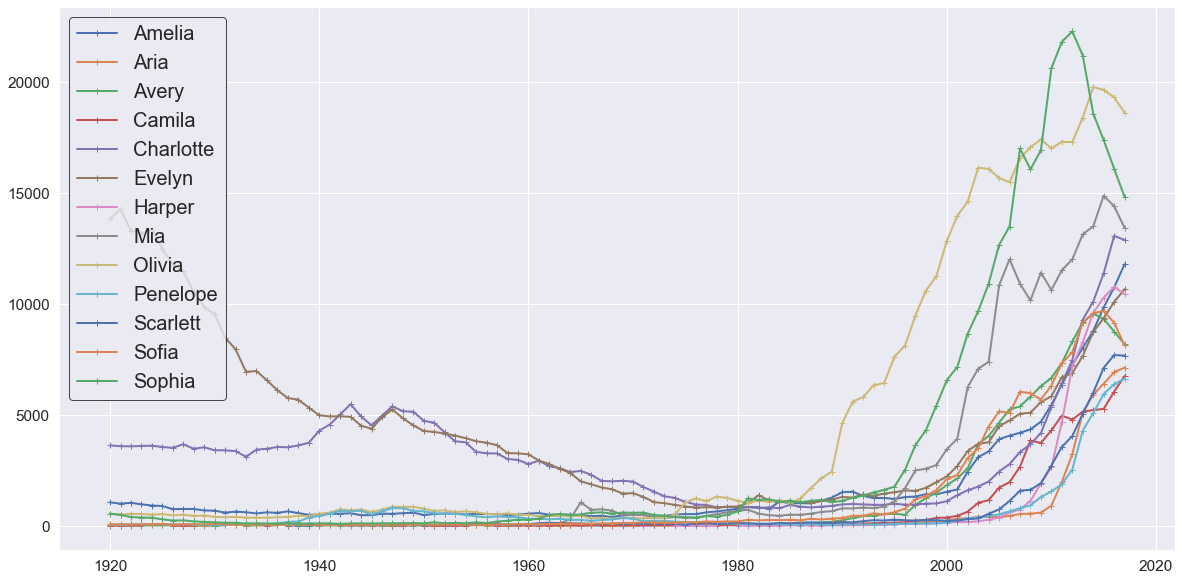

In [121]:
# 画出现在流行的女名字的变化趋势
attr = list(range(1920, 2018))
plt.figure(figsize = (20,10))
for name in girls_names_popular_now:
    v = girls_names_popular_now_data[girls_names_popular_now_data['Name']==name].Count.values
    plt.plot(attr, v, label=name, marker = '+', linewidth=2)
plt.legend(loc = 'upper left', fontsize = 20, frameon = True, edgecolor = 'k', labels = girls_names_popular_now)

### 5. 影响美国人取名字的因素：体育明星、电视明星

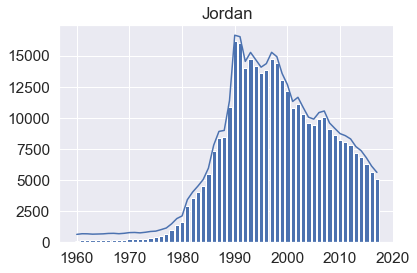

In [141]:
def name_trend(name, data, gender = ['M','F'], year = 1920, dodge = 500):
    # 判断gender是否为str(判断是否输入): isinstance(gender, str)
    if isinstance(gender, str):
        # 挑出符合条件的数据
        name_data = data[(data['Name'] == name)&
                        (data['Gender'] == gender)&
                        (data['Year'] >= year)]
        # 画出折线图和条形图
        attr = name_data['Year'].values
        plt.bar(attr, name_data['Count'].values)
        plt.plot(attr, name_data['Count'].values + dodge)
        plt.title(name)
    else:
        name_data = data[(data['Name'] == name)&
                        (data['Year']>= year)]
        attr = range(year, 2018)
        # 由于性别不确定，现在分别数性别的个数
        v1 = name_data[name_data['Gender']==gender[0]].Count.values
        v2 = name_data[name_data['Gender']==gender[1]].Count.values
        plt.bar(attr, v1)
        plt.bar(attr, v2)
        plt.plot(attr, v1+dodge)
        plt.plot(attr, v2+dodge)
        plt.title(name)
name_trend('Jordan',data,gender='M', year = 1960)

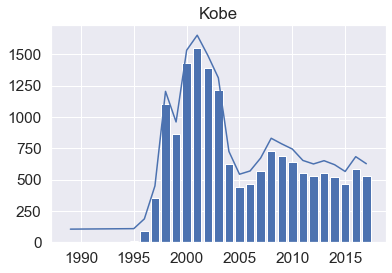

In [135]:
name_trend('Kobe', data, gender = 'M', year = 1920, dodge = 100)

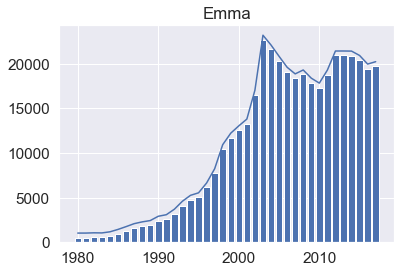

In [136]:
name_trend('Emma', data, gender = 'F', year = 1980)

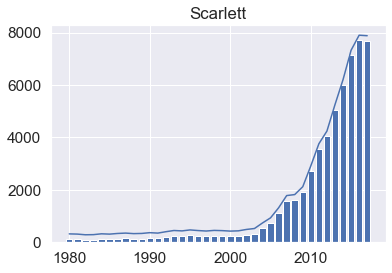

In [137]:
name_trend('Scarlett', data, gender = 'F', year = 1980, dodge = 200)

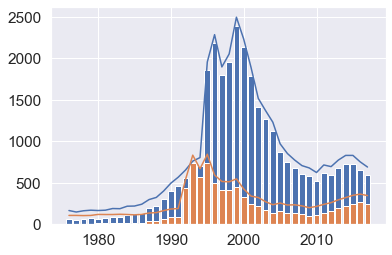

In [138]:
name_trend('Chandler', data, year = 1976, dodge = 100)

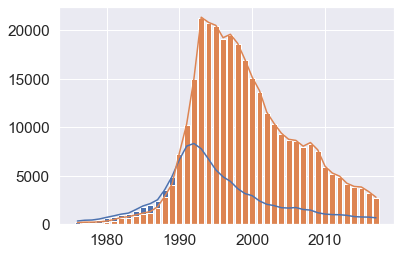

In [139]:
name_trend('Taylor', data, year = 1976, dodge = 100)

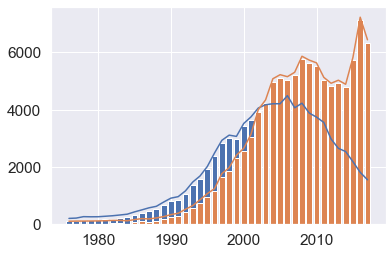

In [140]:
name_trend('Riley', data, year = 1976, dodge = 100)

## 6. 为什么同一发音的名字，有很多不同的拼音变体？

### Catherine/Katharine

In [565]:
# 使用 pd.Series.str.contains('内容').unique()方法筛选出符合条件的名字
Catherine = data['Name'][data['Name'].str.contains('^[C|K]ath')].unique()
Catherine

# 根据名字筛选出数据，根据名字进行聚类后抽取出Count以计算sum
Catherine_data = data[data['Name'].isin(Catherine)].groupby('Name').Count.sum()
Catherine_data

array(['Catherine', 'Katherine', 'Kathryn', 'Katharine', 'Catharine',
       'Kathleen', 'Kathrine', 'Cathrine', 'Katheryn', 'Kathryne',
       'Katharina', 'Katharyn', 'Kathyrn', 'Cathern', 'Cathryn',
       'Kathern', 'Kathrina', 'Katherina', 'Katheryne', 'Katherin',
       'Cathleen', 'Catheryn', 'Kathlyn', 'Catherina', 'Katherene',
       'Kathaleen', 'Catherene', 'Cathryne', 'Katheleen', 'Kathy',
       'Catheryne', 'Kathreen', 'Catherin', 'Kathlene', 'Kathrin',
       'Kathalene', 'Kathelene', 'Kathlyne', 'Kathyleen', 'Kathren',
       'Cather', 'Kathleene', 'Katharyne', 'Kathline', 'Cathren',
       'Cathrin', 'Kathalyn', 'Katherne', 'Kathrene', 'Katherleen',
       'Cathaleen', 'Catheline', 'Katheren', 'Katherlene', 'Kathie',
       'Catherline', 'Cathy', 'Kathlean', 'Katheriene', 'Catha',
       'Cathelene', 'Katholeen', 'Catheren', 'Catherne', 'Katha',
       'Kathaline', 'Cathlyn', 'Katheline', 'Kathlynn', 'Cathaline',
       'Cathreen', 'Katherline', 'Kathrean', 'Cathie', '

Name
Cath           11
Catha         149
Cathal         40
Cathaleen     323
Cathalene      21
             ... 
Kathyria       21
Kathyrine       6
Kathyrn      3167
Kathyrne       10
Kathyy          5
Name: Count, Length: 159, dtype: int64

In [195]:
from pyecharts.charts import Page, WordCloud
from pyecharts.globals import SymbolType

name = list(Catherine_data.index)
value = list(Catherine_data.values)
temp = list(np.zeros(len(value)))
for i in range(len(value)):
    temp[i] = [name[i],value[i]]
word = list(np.zeros(len(value)))
for i in range(len(temp)):
    word[i] = tuple(temp[i])
word
    
wordcloud = WordCloud()
wordcloud.add("", word, word_size_range=[20, 100],shape='diamond')
wordcloud.render_notebook()

## 7. 一些具有特殊含义的名字，有多少人取

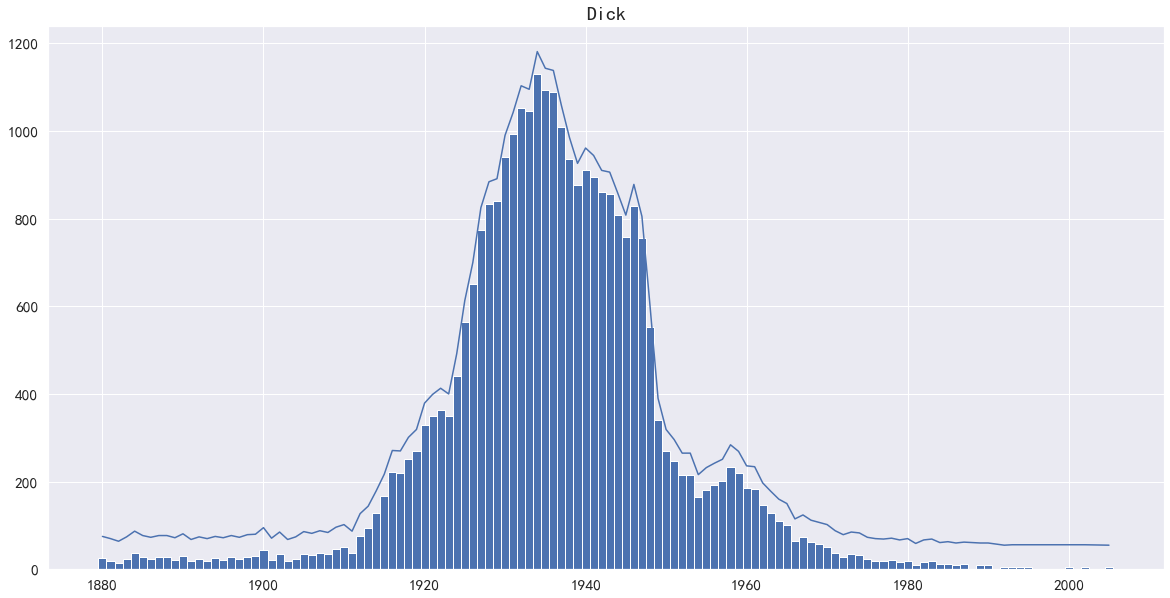

In [566]:
def name_trend2(name, data, gender, dodge = 100):
    name_data = data[(data['Name'] == name) & (data['Gender'] == gender)]
    attr = name_data['Year'].values
    v1 = name_data['Count'].values
    plt.figure(figsize = (20,10))
    plt.bar(attr, v1, width = 1)
    plt.plot(attr, v1+dodge)
    plt.title(name, fontsize = 20)
    
name_trend2('Dick', data, gender = 'M', dodge = 50)

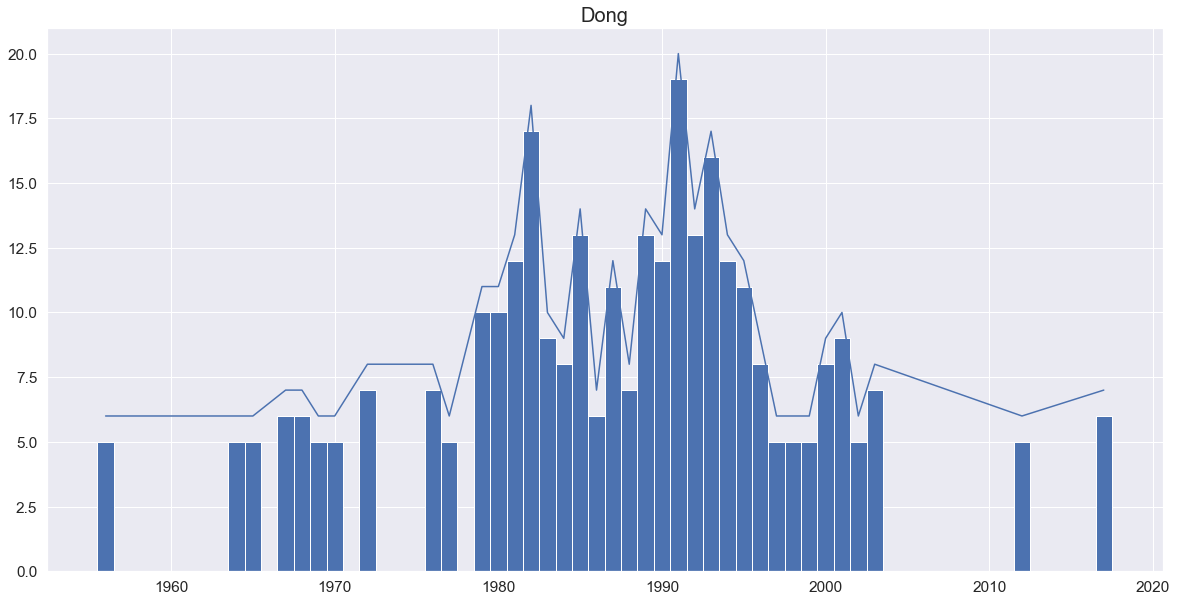

In [212]:
name_trend2('Dong', data, gender = 'M', dodge = 1)

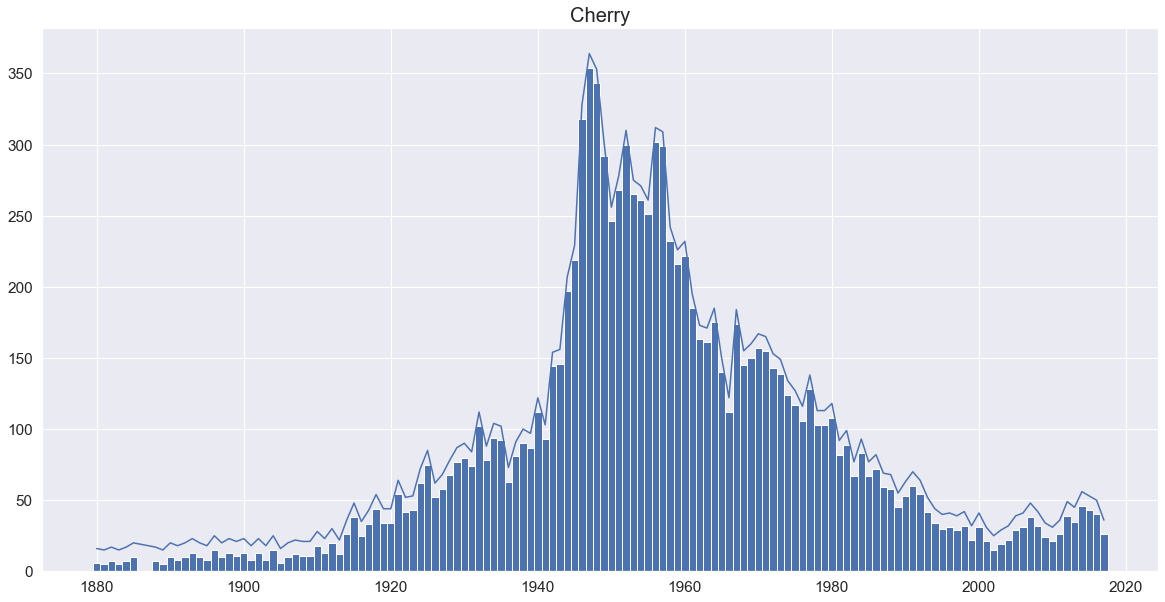

In [214]:
name_trend2('Cherry', data, gender = 'F', dodge = 10)

### 8. 一些特殊的名字

In [217]:
class Solution:
    # @return a string
    def getlongestpalindrome(self, s, l, r):
        while l >= 0 and r < len(s) and s[l] == s[r]:
            l -= 1; r += 1
        return s[l+1 : r]
    
    def longestPalindrome(self, s):
        palindrome = ''
        for i in range(len(s)):
            len1 = len(self.getlongestpalindrome(s, i, i))
            if len1 > len(palindrome):
                palindrome = self.getlongestpalindrome(s, i, i)
            len2 = len(self.getlongestpalindrome(s, i, i+1))
            if len2 > len(palindrome):
                palindrome = self.getlongestpalindrome(s, i, i+1)
        return True if len(palindrome) > 5 else False

In [219]:
a = Solution()
a.longestPalindrome('alfrederfl')

True

In [223]:
all_name = data['Name'].unique()
palindrome_name = []
# 找出Palindrome (迴文)
for name in all_name:
    if a.longestPalindrome(name):
        palindrome_name.append(name)

# 根据Palindrome找出对应数据
palindrome_data = data[data['Name'].isin(palindrome_name)].groupby('Name').Count.sum()
palindrome_data

Name
Austreberto      16
Barabara        181
Bareera          13
Bareerah         15
Basilisa         32
Brenner        1053
Channah         205
Dannylynn         5
Deneene          74
Drakkar         142
Fredderick      134
Geissie          19
Glennell         17
Greggery         16
Habeeba           9
Henretter        79
Jaleela           5
Janellen         40
Jeneene          17
Jennylynn        19
Jhonattan         7
Johannah       2914
Johnattan        91
Jonattan         41
Junellen         12
Kaleela           5
Khaleelah       107
Khalilah       1543
Maryhannah        5
Pacifica          6
Pharrah         132
Rihannah         20
Saharrah         21
Savhannah         5
Shakeeka         14
Shallah          18
Shammah          60
Shannah        1379
Sharrah          21
Shoshannah      223
Staccato         16
Vasilisa        156
Name: Count, dtype: int64

## 附录：一些功能的用法

### pandas筛选数据的常用方法

In [550]:
mydict = {
    'A' : list(np.random.randn(8)),
    'B' : list(np.random.randn(8)),
    'C' : list(np.random.randn(8)),
    'D' : list(np.random.randn(8)),
    'E' : list(np.random.randn(8))
}

df = pd.DataFrame(mydict)

# 1. 求交集
df[(df['B'] > 1) & (df['C'] < 1)]

# 2. 求并集
df[(df['B'] > 1) | (df['C'] < 1)]

# 3. 求给定列的符合条件的行
df[['B','D']][(df['D']>0)|(df['B']>0)]

# 4. 求给定列带有给定字符串的行
df.iloc[5] = 'ac'
df.iloc[6] = 'aaa'
df[df['C'].isin(['aaa', 'ac'])]


newdict = {
    '区域' : ['四川A','四川A','四川A','重庆A', '重庆B', '重C'],
    '销售' : [np.round(np.random.rand(),1) for i in range(6)],
    '人员数量': list(np.linspace(1, 10, 6))
}

newdf = pd.DataFrame(newdict)
newdf

# 5. 用str.contain()进行字符串的模糊筛选
newdf[newdf['区域'].str.contains('四川|A')]


,A,B,C,D,E
1,-0.880989,2.469304,-2.054531,0.128865,-0.211185


,A,B,C,D,E
0,1.557075,-0.306494,-0.900489,0.415282,0.545451
1,-0.880989,2.469304,-2.054531,0.128865,-0.211185
2,0.020224,0.078266,-2.127366,0.167175,0.932947
3,0.074094,-1.806637,-2.315401,-0.010096,-1.112725
4,0.462422,-0.519806,-1.185287,0.917000,0.280813
5,0.161615,-0.212735,-0.916129,0.107615,-1.394265
6,-0.449157,0.217215,-0.168681,0.370235,1.151065
7,-0.387882,-1.627040,0.101288,-0.326927,1.420482


,B,D
0,-0.306494,0.415282
1,2.469304,0.128865
2,0.078266,0.167175
4,-0.519806,0.917000
5,-0.212735,0.107615
6,0.217215,0.370235


,A,B,C,D,E
5,ac,ac,ac,ac,ac
6,aaa,aaa,aaa,aaa,aaa


,区域,销售,人员数量
0,四川A,0.5,1.0
1,四川A,0.3,2.8
2,四川A,0.3,4.6
3,重庆A,0.2,6.4
4,重庆B,0.9,8.2
5,重C,0.7,10.0


,区域,销售,人员数量
0,四川A,0.5,1.0
1,四川A,0.3,2.8
2,四川A,0.3,4.6
3,重庆A,0.2,6.4


### 使用melt函数重构数据集
df.melt()可以把款数据集变为长数据集
![图片](https://img-blog.csdn.net/20180927155514513?watermark/2/text/aHR0cHM6Ly9ibG9nLmNzZG4ubmV0L21pbmdrb3Vrb3U=/font/5a6L5L2T/fontsize/400/fill/I0JBQkFCMA==/dissolve/70)

In [496]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" 

df = pd.DataFrame({'A': {0: 'a', 1: 'b', 2: 'c'},
                    'B': {0: 1, 1: 3, 2: 5},
                    'C': {0: 2, 1: 4, 2: 6}})
df

# 直接把宽数据框准换为长数据框
df.melt(id_vars = ['A'])

# 只保留B列
df.melt(id_vars = ['A'], value_vars = ['B'])

# 保留 B C 列(和df.melt(id_vars = ['A'])的效果是一样的)
df.melt(id_vars = ['A'], value_vars = ['B', 'C'])

# 自定义列名
df.melt(id_vars = ['A'], value_vars = ['B', 'C'], var_name = 'myVarname', value_name = 'myValue')

# 把数据框弄成双columns的
df.columns = [list('ABC'), list('DEF')]
df
# 再度melt
# df.melt(col_level = 0, id_vars = ['A'] value_vars = ['B'])

# 多个id_vars和value_vars的情况
df.melt(id_vars = [('A', 'D')], value_vars = [('B', 'E')])

,A,B,C
0,a,1,2
1,b,3,4
2,c,5,6


,A,variable,value
0,a,B,1
1,b,B,3
2,c,B,5
3,a,C,2
4,b,C,4
5,c,C,6


,A,variable,value
0,a,B,1
1,b,B,3
2,c,B,5


,A,variable,value
0,a,B,1
1,b,B,3
2,c,B,5
3,a,C,2
4,b,C,4
5,c,C,6


,A,myVarname,myValue
0,a,B,1
1,b,B,3
2,c,B,5
3,a,C,2
4,b,C,4
5,c,C,6


,A,B,C
,D,E,F
0,a,1,2
1,b,3,4
2,c,5,6


,"(A, D)",variable_0,variable_1,value
0,a,B,E,1
1,b,B,E,3
2,c,B,E,5


### pd.pivot()和pd.melt()的转化

In [495]:
df = pd.DataFrame({'A': {0: 'a', 1: 'b', 2: 'c'},
                    'B': {0: 1, 1: 3, 2: 5},
                    'C': {0: 2, 1: 4, 2: 6}})
df

df_melt = df.melt(id_vars = ['A'])
df_melt

df_pivot = df_melt.pivot(index = 'A', columns = 'variable').reset_index()
df_pivot

,A,B,C
0,a,1,2
1,b,3,4
2,c,5,6


,A,variable,value
0,a,B,1
1,b,B,3
2,c,B,5
3,a,C,2
4,b,C,4
5,c,C,6


A value   
variable        B  C
0         a     1  2
1         b     3  4
2         c     5  6

### 使用pd.reset_index()重置index

In [50]:
import sys

df1 = pd.DataFrame({ 'A': ['A0', 'A1', 'A2', 'A3'],
                     'B': ['B0', 'B1', 'B2', 'B3'],
                     'C': ['C0', 'C1', 'C2', 'C3'],
                     'D': ['D0', 'D1', 'D2', 'D3']})
                     
df2 = pd.DataFrame({'A': ['A4', 'A5', 'A6', 'A7'],
                     'B': ['B4', 'B5', 'B6', 'B7'],
                     'C': ['C4', 'C5', 'C6', 'C7'],
                     'D': ['D4', 'D5', 'D6', 'D7']})
                     
df3 = pd.DataFrame({'A': ['A8', 'A9', 'A10', 'A11'],
                     'B': ['B8', 'B9', 'B10', 'B11'],
                     'C': ['C8', 'C9', 'C10', 'C11'],
                     'D': ['D8', 'D9', 'D10', 'D11']})
frames = [df1, df2, df3]
result = pd.concat(frames)
result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
0,A4,B4,C4,D4
1,A5,B5,C5,D5
2,A6,B6,C6,D6
3,A7,B7,C7,D7
0,A8,B8,C8,D8
1,A9,B9,C9,D9


In [53]:
# 可见index没有按照123456...这样的顺序排列下去
# 使用result.reset_index
result = result.reset_index(drop=True)
result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


### pandas.iloc()的用法

In [581]:
mydict = [{'a': 1, 'b': 2, 'c': 3, 'd': 4},
...           {'a': 100, 'b': 200, 'c': 300, 'd': 400},
...           {'a': 1000, 'b': 2000, 'c': 3000, 'd': 4000 }]

df = pd.DataFrame(mydict)
df.iloc[lambda x:x.index%2==0]
df.iloc[[True,True,False]]



,a,b,c,d
0,1,2,3,4
2,1000,2000,3000,4000


,a,b,c,d
0,1,2,3,4
1,100,200,300,400


[-1.6323586366963097,
 1.2633679478019264,
 -1.3374072021647887,
 -0.5949796648989263,
 0.44802263904556705,
 -1.7600148866229628,
 0.006066408887919996,
 0.7971945227804107,
 -0.7326313031792651,
 -1.3904655328989952]

[0.006066408887919996,
 0.44802263904556705,
 -0.5949796648989263,
 -0.7326313031792651,
 0.7971945227804107,
 1.2633679478019264,
 -1.3374072021647887,
 -1.3904655328989952,
 -1.6323586366963097,
 -1.7600148866229628]

### pyecharts.Line()的用法

In [1]:
import pyecharts.options as opts
from pyecharts.faker import  Faker
from pyecharts.charts import Line


def line_base() -> Line:
    c = (
        Line()
        .add_xaxis(Faker.choose())
        .add_yaxis("商家A", Faker.values())
        .add_yaxis("商家B", Faker.values())
        .set_global_opts(title_opts=opts.TitleOpts(title="Line-基本示例"))
    )
    return c
line_base().render_notebook()


### 利用pd.corrwith(比较对象, axis, method)来DataFrame的给定行或列进行相关性分析
<https://blog.csdn.net/w1301100424/article/details/98473560>

In [231]:
data1 = np.array([[5, 5, 3, 3, 4], [3, 4, 5, 5, 4],
                 [3, 4, 3, 4, 5], [5, 5, 3, 4, 4]])
columnNames = ['The Shawshank Redemption', 'Forrest Gump', 'Avengers: Endgame',
                                 'Iron Man', 'Titanic ']
indexNames = ['user1', 'user2', 'user3', 'user4']
df = pd.DataFrame(data1, columns = columnNames, index = indexNames)

# 分析user1和其他user之间的相关性
user_to_compare = df.iloc[0]
similarity_with_other_users = df.corrwith(user_to_compare, axis = 1,
                                         method = 'pearson')
similarity_with_other_users.sort_values(ascending = False)

# 分析The Shawshank Redemption和其他电影之间的关系
movie_to_compare = df['The Shawshank Redemption']
similarity_with_other_movies = df.corrwith(movie_to_compare, axis = 0, method = 'pearson')
similarity_with_other_movies.sort_values(ascending = False)

Forrest Gump                1.000000
The Shawshank Redemption    1.000000
Titanic                    -0.577350
Avengers: Endgame          -0.577350
Iron Man                   -0.707107
dtype: float64

### pandas.DataFrame.sort_values()方法

In [280]:
df = pd.DataFrame({
    'col1': ['A', 'A', 'B', np.nan, 'D', 'C'],
    'col2': [2, 1, 9, 8, 7, 4],
    'col3': [0, 1, 9, 4, 2, 3]
})
print(df)

  col1  col2  col3
0    A     2     0
1    A     1     1
2    B     9     9
3  NaN     8     4
4    D     7     2
5    C     4     3


In [281]:
print(df.sort_values(by = 'col1'))

  col1  col2  col3
0    A     2     0
1    A     1     1
2    B     9     9
5    C     4     3
4    D     7     2
3  NaN     8     4


In [285]:
print(df.sort_values(by = ['col1', 'col2'], ascending = True))

  col1  col2  col3
1    A     1     1
0    A     2     0
2    B     9     9
5    C     4     3
4    D     7     2
3  NaN     8     4


In [287]:
# 把缺失值放到最前
print(df.sort_values(by = 'col1', ascending = False, na_position = 'first'))

  col1  col2  col3
3  NaN     8     4
4    D     7     2
5    C     4     3
2    B     9     9
0    A     2     0
1    A     1     1


### pandas.cut()的用法

In [315]:
# 创建DataFrame
df = pd.DataFrame()
score_list = np.random.randint(25,100,size=20)
df['score'] = score_list
df['student'] = [pd.util.testing.rands(3) for i in range(len(score_list))]

# 设定分箱依据bins
bins = [0, 59, 70, 80, 100]

# 使用pd.cut方法进行分箱
df['Categories'] = pd.cut(df['score'], bins)

# 还可以增加labels
Labels = ['low', 'middle', 'good', 'perfect']
df['labels'] = pd.cut(df['score'], bins, labels=Labels)
df

,score,student,Categories,labels
0,71,aWf,"(70, 80]",good
1,77,ucr,"(70, 80]",good
2,32,ZqK,"(0, 59]",low
3,50,HJJ,"(0, 59]",low
4,48,h0E,"(0, 59]",low
5,86,U3t,"(80, 100]",perfect
6,45,2nk,"(0, 59]",low
7,85,EtX,"(80, 100]",perfect
8,91,RiB,"(80, 100]",perfect
9,97,JBo,"(80, 100]",perfect


### pandas.levels()方法的使用
<https://blog.csdn.net/qq_36523839/article/details/80468063>

In [588]:
df = pd.DataFrame({'df1':['cat','cat','dog','cat','dog','dog'],'df2':[2,3,4,1,3,1],'df3':[100,200,100,300,200,200]})
df
# 对df1进行排序
def sort_df2(data):
    data = data.sort_values(by = 'df2', ascending = False)
    return data

# 注意df.sort_values(by = ['df1','df2'])和df.groupby(df['df1']).apply(sort_df2)的区别
# 前者是逐步排序。后者是进行聚类之后再进行排序。关键区别是，后者有两个levels
df.sort_values(by = ['df1','df2'])
group = df.groupby(df['df1']).apply(sort_df2)

# 看看group的index. 可见有两层分级：cat/dog和0/1/2/3/4/5
print(group.index)

# 用pd.index.levels[0]取出第一层级
levels = group.index.levels[0]

# 从中选出物种前两个品种及其价格
values = []
for i in levels:
    # 取出第i个标签的物种的所有品种
    mid_group = group.loc[i]
    # 取出第i个标签的物种的前两个品种
    mid_group = mid_group.iloc[:2, :]
    for j in range(len(mid_group)):
        # 取出第i个标签的物种中第j个品种编号和价格，并化为tuple
        value = mid_group.iloc[j,:]
        value_pro = (value['df2'], value['df3'])
        values.append(value_pro)
values


# ----------------更新-----------------
df = pd.DataFrame({'df1':['cat','cat','dog','cat','dog','dog'],'df2':[2,3,4,1,3,1],'df3':[100,200,100,300,200,200],'df4':['大','中','小','巨大','小','中']})
# 查看不同物种的大中小型分类下的数量: df.groupby().size()
df_group = df.groupby(['df1','df4']).size()

# 从df_group中提取出猫物种的体型.注意，由于df_group是两侧索引的，loc也应该制定复合索引
h = df_group.loc[['cat','df4']]
# 还有，pd.Series也能用loc，而且不用指定列

# 获得第一层的分类cat、dog
df1_name = df_group.index.levels[0]

for i in range(len(df1_name)):
    df_levels = df_group.loc[[df1_name[i], 'df4']]
    df_levels_ch = pd.DataFrame(df_levels)
    for j in range(len(df_levels_ch)):
        a = df_levels_ch.ix[j].name
        b = df_levels_ch.values[j][0]
        print(a,b)



,df1,df2,df3
0,cat,2,100
1,cat,3,200
2,dog,4,100
3,cat,1,300
4,dog,3,200
5,dog,1,200


,df1,df2,df3
3,cat,1,300
0,cat,2,100
1,cat,3,200
5,dog,1,200
4,dog,3,200
2,dog,4,100


MultiIndex([('cat', 1),
            ('cat', 0),
            ('cat', 3),
            ('dog', 2),
            ('dog', 4),
            ('dog', 5)],
           names=['df1', None])


[(3, 200), (2, 100), (4, 100), (3, 200)]

('cat', '中') 1
('cat', '大') 1
('cat', '巨大') 1
('dog', '中') 1
('dog', '小') 2


D:\Anaconda\lib\site-packages\ipykernel_launcher.py:50: FutureWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ix-indexer-is-deprecated


df1    cat
df2      3
df3    200
Name: (cat, 1), dtype: object

### 使用groupby(level = 0)对重复索引进行切割

In [404]:
lst = [1, 2, 3, 1, 2, 3]
s = pd.Series([1, 2, 3, 10, 20, 30], lst)
grouped = s.groupby(level = 0)
grouped.first()

1    1
2    2
3    3
dtype: int64

In [405]:
grouped.last()

1    10
2    20
3    30
dtype: int64

In [412]:
grouped.sum()

1    11
2    22
3    33
dtype: int64

### index.get_level_values()和index.values()的区别

In [425]:
# 前者只是显示index层3的种类
print(decade.index.levels[3])
# 后者显示出不同样本对应的index层3的类型
decade.index.get_level_values(3)

Index(['F', 'M'], dtype='object', name='Gender')


Index(['F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M',
       'F', 'M', 'F', 'M', 'F', 'M'],
      dtype='object', name='Gender')

### 查看所有可用的颜色

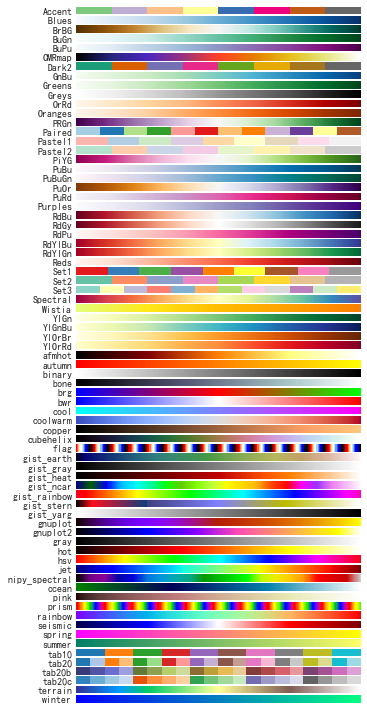

In [436]:
a = np.linspace(0, 1, 256).reshape(1,-1)
a = np.vstack((a,a))

# Get a list of the colormaps in matplotlib.  Ignore the ones that end with
# '_r' because these are simply reversed versions of ones that don't end
# with '_r'
maps = sorted(m for m in plt.cm.datad if not m.endswith("_r"))
nmaps = len(maps) + 1

fig = plt.figure(figsize=(5,10))
fig.subplots_adjust(top=0.99, bottom=0.01, left=0.2, right=0.99)
for i,m in enumerate(maps):
    ax = plt.subplot(nmaps, 1, i+1)
    plt.axis("off")
    plt.imshow(a, aspect='auto', cmap=plt.get_cmap(m), origin='lower')
    pos = list(ax.get_position().bounds)
    fig.text(pos[0] - 0.01, pos[1], m, fontsize=10, horizontalalignment='right')

plt.show()

### 关于sorted函数key的用法

In [582]:
test2 = list(np.random.randn(10))
test2
sorted(test2, key = lambda x: np.abs(x))

[-0.7818034513587317,
 -0.1102743345767543,
 0.4265265488293333,
 -0.6394929879827599,
 -1.8497534585818527,
 0.3157240964531329,
 0.3969650015299036,
 -1.1410492773352041,
 0.42745796566669214,
 0.28101846654344065]

[-0.1102743345767543,
 0.28101846654344065,
 0.3157240964531329,
 0.3969650015299036,
 0.4265265488293333,
 0.42745796566669214,
 -0.6394929879827599,
 -0.7818034513587317,
 -1.1410492773352041,
 -1.8497534585818527]